In [ ]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt

/usr/local/lib/python3.6/dist-packages/pandas_datareader/compat/__init__.py:7: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  from pandas.util.testing import assert_frame_equal


In [ ]:
df = web.DataReader('AAPL', 'yahoo', start='2019-09-10', end='2019-10-09')
df.tail(3)

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2019-10-07,57.482498,56.459999,56.567501,56.764999,122306000,56.207317
2019-10-08,57.014999,56.082500,56.455002,56.099998,111820000,55.548851
2019-10-09,56.947498,56.410000,56.757500,56.757500,74770400,56.199894


In [ ]:
web.DataReader('GDP', 'fred', start='2000-01-01').tail(3)

,GDP
DATE,
2019-10-01,21747.394
2020-01-01,21561.139
2020-04-01,19486.509


In [ ]:
web.DataReader(['^SPX'], 'yahoo', start='2019-09-10', end='2020-10-09')

Attributes,Adj Close,Close,High,Low,Open,Volume
Symbols,^SPX,^SPX,^SPX,^SPX,^SPX,^SPX
Date,,,,,,
2020-09-23,3236.919922,3236.919922,3323.350098,3232.570068,3320.110107,2462124190


In [ ]:
price = web.DataReader(['AAPL', 'MSFT', 'FB', 'TSLA', 'M', 'AMZN', 'SPY'], 'yahoo', start='2019-10-01')['Adj Close']
price.fillna(method='ffill')
price.tail(3)

Symbols,AAPL,MSFT,FB,TSLA,M,AMZN,SPY
Date,,,,,,,
2020-09-21,110.080002,202.539993,248.149994,449.390015,6.31,2960.469971,326.970001
2020-09-22,111.809998,207.419998,254.750000,424.230011,6.27,3128.989990,330.299988
2020-09-23,107.120003,200.589996,249.020004,380.359985,6.11,2999.860107,322.640015


In [ ]:
daily_return = price.pct_change()
daily_return.dropna(inplace=True)
daily_return.tail()

Symbols,AAPL,MSFT,FB,TSLA,M,AMZN,SPY
Date,,,,,,,
2020-09-17,-0.015964,-0.010436,-0.033015,-0.041493,-0.017192,-0.022537,-0.008795
2020-09-18,-0.031720,-0.012419,-0.008987,0.044210,-0.014577,-0.017888,-0.011513
2020-09-21,0.030326,0.010729,-0.017344,0.016375,-0.066568,0.001882,-0.011130
2020-09-22,0.015716,0.024094,0.026597,-0.055987,-0.006339,0.056923,0.010184
2020-09-23,-0.041946,-0.032928,-0.022493,-0.103411,-0.025518,-0.041269,-0.023191


In [ ]:
standardize = lambda x: (x-x.mean()) / x.std()
standardized_return = standardize(daily_return)
standardized_return.head()

Symbols,AAPL,MSFT,FB,TSLA,M,AMZN,SPY
Date,,,,,,,
2019-10-02,-1.000842,-0.726863,-0.316970,-0.290487,-1.023688,-0.681574,-0.882104
2019-10-03,0.193688,0.376388,0.935862,-0.918082,0.224800,0.179869,0.361110
2019-10-04,0.889041,0.428146,0.152846,-0.299243,0.235282,0.281759,0.617828
2019-10-07,-0.100809,-0.340762,-0.221333,0.308341,0.122897,-0.287400,-0.240244
2019-10-08,-0.525595,-0.464376,-0.458087,-0.001786,-0.194565,-0.803476,-0.779217


In [ ]:
standardized_return.corr().tail(1)

Symbols,AAPL,MSFT,FB,TSLA,M,AMZN,SPY
Symbols,,,,,,,
SPY,0.847,0.884575,0.759279,0.470802,0.55686,0.62183,1.0


In [ ]:
standardized_return.shape[1]

7

In [ ]:
ingredients = standardized_return.iloc[:,:-1].copy()
ingredients.tail(3)

Symbols,AAPL,MSFT,FB,TSLA,M,AMZN
Date,,,,,,
2020-09-21,0.970682,0.325364,-0.699561,0.115523,-1.182967,-0.026088
2020-09-22,0.450697,0.820813,0.907337,-1.175884,-0.079053,2.411854
2020-09-23,-1.601556,-1.293044,-0.887824,-2.022238,-0.430581,-1.937335


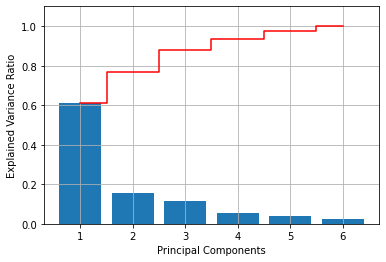

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 


pca = PCA(n_components=ingredients.shape[1])
pca.fit(ingredients)
explained_variance_ratio = pca.explained_variance_ratio_

def explained_variance_ratio_plot(explained_variance_ratio):
    x_axis = range(1, len(explained_variance_ratio)+1)
    plt.bar(x_axis, explained_variance_ratio,
            align = 'center', label = 'Individual Explained Variance Ratio')
    plt.step(x_axis, np.cumsum(explained_variance_ratio),
             where = 'mid', color='red', label='Cumulative Explained Variance Ratio')
    plt.ylim(0, 1.1)
    plt.xticks(x_axis)
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.grid()
    plt.show()
   
explained_variance_ratio_plot(explained_variance_ratio)

In [ ]:
pca = PCA(n_components=1)
pca.fit(ingredients)
newIndex = pca.fit_transform(ingredients)
pc1 = newIndex[:, 0]

# Coefficients
loadings = pd.DataFrame(pca.components_.T, columns = ['PC1'], index = ingredients.columns)

result = pd.DataFrame(ingredients)
result['SPY'] = standardized_return['SPY']
result['PC1'] = pc1

abs(result.corr()['PC1'])

Symbols
AAPL    0.911141
MSFT    0.928091
FB      0.863056
TSLA    0.638126
M       0.406471
AMZN    0.814527
SPY     0.893527
PC1     1.000000
Name: PC1, dtype: float64

In [ ]:
abs(loadings).rank(ascending=False)

,PC1
Symbols,
AAPL,2.0
MSFT,1.0
FB,3.0
TSLA,5.0
M,6.0
AMZN,4.0


In [1]:
import talib

ModuleNotFoundError: ignored